In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from collections import Counter
import json
import os
import math

from lifelines import KaplanMeierFitter
from scipy.stats import linregress



In [23]:
# experiment_uuid = "21b3782a-4c2e-4fee-b745-80b310113b91"
experiment_uuid = "17bb023c-f0e5-4919-b305-2b3682fbbb0d"

full_experiment_df = pd.read_csv(f"{experiment_uuid}.csv")

FileNotFoundError: [Errno 2] No such file or directory: '17bb023c-f0e5-4919-b305-2b3682fbbb0d.csv'

In [24]:
!pwd

/Users/thomas/Desktop/git/scriptie/agent-based-motherese/src


In [25]:
runs = [
    "57e552b4-83eb-415a-b16a-2f11da7883d4",
    "67f58c2a-67e9-4e30-ad24-eef1da95f150",
    "deffadf2-d33d-48ad-a0ce-82081a071ee6",
    "38050ea3-e832-480f-9a6f-9c210e1615f5",
    "006e3ad8-842d-464a-80f4-5c6551f4af06",
    "c732b302-9581-49dd-b4ad-6230516864f9",
    "8aa99e6c-af03-4e17-be67-08b3f0cf6b6e",
    "8ffca7b0-9cfc-4a30-aac8-c69b5087b0f4",
    "f3a93f13-0545-462d-afa9-035d5f819a6f",
    "fec68c59-3263-4a57-9cc8-ea9c382e3a20",
    "7330c41f-cbe9-4c15-8307-53a50465bd17",
    "05a5caff-e50f-44ee-9db6-bfd860de2196",
    "225ce47f-d12f-463d-92d5-6e47d389ac9b",
    "4192e1a6-33bd-4ea4-abbc-c01f80c0022d",
    "faecfebd-baaf-43a5-be00-9946e0ed325e",
    "8f53b511-591b-4818-8e2a-a29acb94774f",
    "1079c811-1b37-43fc-a207-2121184d7774",
    "4f31a155-722f-4c92-bbb8-c52392edcc60",
    "311fd9c6-0bc6-4325-90b4-18df1ad298b5",
    "1ae518ae-2d48-4407-b5a7-bff8ddeffa57",
    "a24c0161-8466-49b0-b560-142724700066",
    "4c2a6699-d9e2-40ca-81f7-db1cbcfce2a0",
    
    
]

df = pd.DataFrame()

for run in runs:
    run_df = pd.read_csv(f"/Users/thomas/Desktop/git/scriptie/agent-based-motherese/src/data/logs/{run}/metrics_data.csv")
    df = pd.concat([df, run_df])
    
full_experiment_df = df


In [26]:
# full_experiment_df = pd.read_csv("/Users/thomas/Desktop/git/scriptie/agent-based-motherese/src/data/experiments/187053e1-0cc6-455d-b4e3-94ebf6cdb98a/full_metrics_data.csv")
full_experiment_df = pd.read_csv("/Users/thomas/Desktop/git/scriptie/agent-based-motherese/src/data/experiments/2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048/full_metrics_data.csv")


In [27]:
full_experiment_df = full_experiment_df.drop_duplicates()

In [28]:
full_experiment_df.iloc[0:10]

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,mean_message_length,ub_message_length,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp,experiment_uuid
0,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,1,3,[1. 1. 1. ... 1. 1. 1.],0.720500,1.600057,-0.159057,0.448754,0.201380,...,2.819375,4.918268,0.720482,1.070864,1.146750,22555.000305,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:04.047153,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
1,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,2,3,[1. 1. 1. ... 1. 1. 0.],0.819750,1.573165,0.066335,0.384396,0.147760,...,2.839625,4.959603,0.719647,1.081621,1.169905,22716.999054,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:21.969439,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
2,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,3,3,[0. 1. 1. ... 1. 1. 0.],0.817125,1.574790,0.059460,0.386564,0.149432,...,2.866125,5.060058,0.672192,1.119353,1.252952,22929.000854,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:40.667887,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
3,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,1,3,[1. 1. 1. ... 1. 1. 1.],0.720500,1.600057,-0.159057,0.448754,0.201380,...,2.819375,4.918268,0.720482,1.070864,1.146750,22555.000305,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:04.047153,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
5,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,2,3,[1. 1. 1. ... 1. 1. 0.],0.819750,1.573165,0.066335,0.384396,0.147760,...,2.839625,4.959603,0.719647,1.081621,1.169905,22716.999054,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:21.969439,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
7,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,3,3,[0. 1. 1. ... 1. 1. 0.],0.817125,1.574790,0.059460,0.386564,0.149432,...,2.866125,5.060058,0.672192,1.119353,1.252952,22929.000854,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:40.667887,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
9,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,1,3,[1. 1. 1. ... 1. 1. 1.],0.825625,1.569311,0.081939,0.379432,0.143968,...,2.656750,4.682701,0.630799,1.033649,1.068429,21253.999710,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:58.630382,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
10,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,2,3,[1. 1. 1. ... 1. 1. 1.],0.838500,1.559763,0.117237,0.367992,0.135418,...,2.656375,4.705299,0.607451,1.045369,1.092797,21250.999451,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:16.654605,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
11,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,3,3,[1. 1. 1. ... 1. 1. 1.],0.880750,1.515952,0.245548,0.324082,0.105029,...,2.632875,4.689562,0.576187,1.049330,1.101094,21062.999725,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:34.251545,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048
12,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,2,1,3,[1. 1. 1. ... 1. 1. 1.],0.877375,1.520267,0.234483,0.328006,0.107588,...,2.664000,4.708989,0.619011,1.043362,1.088604,21312.000275,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:51.692443,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048


In [29]:
print(f"{len(full_experiment_df['run_uuid'].unique())} runs")

1 runs


In [39]:
epochs_per_round = full_experiment_df["epochs_per_round"].iloc[0]

# full_experiment_df["full_epoch"] = np.where(
#             full_experiment_df["control_group"] == False,
#             full_experiment_df["round"] * full_experiment_df["epochs_per_round"] + full_experiment_df["epoch"].astype(int),
#             full_experiment_df["epoch"] + np.where(full_experiment_df["round"] >= 1, epochs_per_round, 0)
#         )
full_experiment_df["full_epoch"] = full_experiment_df["round"] * full_experiment_df["epochs_per_round"] + full_experiment_df["epoch"].astype(int)

max_full_epoch = full_experiment_df['full_epoch'].max()


def check_completion(series, max_full_epoch):
    run_uuid = series.name
    run_data = full_experiment_df[full_experiment_df['run_uuid'] == run_uuid]
    max_round = run_data['round'].max()
    n_epochs = run_data['epochs_per_round'].iloc[0]

    print(f"Run: {run_uuid}")
    print(f"max_round: {max_round}")
    print(f"n_epochs: {n_epochs}")
    print(f"max_full_epoch: {max_full_epoch}")
    print(f"expected: {(max_round + 1) * n_epochs}")

    result = max_full_epoch == (max_round + 1) * n_epochs
    print(f"completed: {result}\n")
    return result

df = full_experiment_df.copy()
df['completed'] = df.groupby('run_uuid')['full_epoch'].transform(lambda x: check_completion(x, max_full_epoch))

Run: fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf
max_round: 2
n_epochs: 3
max_full_epoch: 9
expected: 9
completed: True



In [40]:
df = df.loc[df["completed"] == True]


In [41]:
df = df.drop_duplicates()

In [42]:

def validate_and_deduplicate_runs(df: pd.DataFrame) -> pd.DataFrame:
    cleaned_df = df.copy()

    groups = 2
    most_common_epochs = stats.mode(df["epochs_per_round"], keepdims=False).mode
    expected_rows = groups * most_common_epochs * len(df["round"].unique())

    row_counts = df['run_uuid'].map(Counter(df['run_uuid']))
    invalid_runs = df.loc[row_counts != expected_rows, "run_uuid"].unique()

    if len(invalid_runs) == 0:
        return cleaned_df

    print(f"Found {len(invalid_runs)} runs with incorrect row count (expected {expected_rows}):")
    print(invalid_runs)

    problem_df = df[df['run_uuid'].isin(invalid_runs)].copy()
    epoch_counts = problem_df['full_epoch'].map(Counter(problem_df['full_epoch']))
    duplicate_df = problem_df.loc[epoch_counts != groups].copy()

    if duplicate_df.empty:
        return cleaned_df

    duplicate_df['timestamp'] = pd.to_datetime(duplicate_df['timestamp'])

    control_dupes = len(duplicate_df.loc[duplicate_df["control_group"]]) > 1
    experiment_dupes = len(duplicate_df.loc[~duplicate_df["control_group"]]) > 1

    if control_dupes:
        print("Found duplicates in control group")
        reference_time = duplicate_df.loc[~duplicate_df["control_group"], "timestamp"].iloc[0]
        duplicate_df.loc[duplicate_df["control_group"], "time_diff"] = (
            duplicate_df.loc[duplicate_df["control_group"], "timestamp"] - reference_time
        ).abs()

    elif experiment_dupes:
        print("Found duplicates in experiment group")
        reference_time = duplicate_df.loc[duplicate_df["control_group"], "timestamp"].iloc[0]
        duplicate_df.loc[~duplicate_df["control_group"], "time_diff"] = (
            duplicate_df.loc[~duplicate_df["control_group"], "timestamp"] - reference_time
        ).abs()

    if control_dupes or experiment_dupes:
        duplicate_df = duplicate_df.sort_values('time_diff')
        rows_to_keep = duplicate_df.drop_duplicates(
            subset=['run_uuid', 'round', 'epoch', 'full_epoch'],
            keep='first'
        ).index
        rows_to_remove = duplicate_df.index.difference(rows_to_keep)

        cleaned_df = cleaned_df.drop(rows_to_remove)

    return cleaned_df


df = validate_and_deduplicate_runs(df)


In [43]:
groups = 2
rows_req = groups * stats.mode(df["epochs_per_round"]).mode * len(df["round"].unique())

run_uuid = df[df['run_uuid'].map(Counter(df['run_uuid'])) != rows_req]["run_uuid"].unique()

incorrect_epochs = [73]
df.loc[df['run_uuid'].isin(run_uuid)][df.loc[df['run_uuid'].isin(run_uuid)]["full_epoch"].isin(incorrect_epochs)]

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp,experiment_uuid,full_epoch,completed


In [133]:
import numpy as np
import pandas as pd
import scipy.stats as stats

def perform_wilcoxon(df, metrics=['mean_accuracy', 'var_accuracy', 'topographic_similarity'], split = 'full_epoch'):
    results = {}

    # print(df[df['control_group'] == True][split])
    # print(df[df['control_group'] == False][split])

    for metric in metrics:
        stat_list, p_value_list = [], []

        for exp_id in df[split].unique():
            # Extract paired time-series for this experiment
            control = df[(df[split] == exp_id) & (df['control_group'] == True)][metric]
            experimental = df[(df[split] == exp_id) & (df['control_group'] == False)][metric]

            if len(control) != len(experimental):
                raise ValueError(f"Experiment {exp_id}: Wilcoxon requires paired data but got {len(control)} and {len(experimental)}")

            stat, p_value = stats.wilcoxon(control, experimental)

            stat_list.append(stat)
            p_value_list.append(p_value)

        # Store summary statistics
        results[metric] = {
            'mean_statistic': np.mean(stat_list),
            'median_statistic': np.median(stat_list),
            'mean_p_value': np.mean(p_value_list),
            'median_p_value': np.median(p_value_list),
            'p_values': p_value_list  # Store all individual p-values if needed
        }

    return results

test = perform_wilcoxon(df[df["round"]>0], metrics=['mean_accuracy'])

plt.plot(test["mean_accuracy"]['p_values'])


ValueError: Experiment 4: Wilcoxon requires paired data but got 2 and 1

In [134]:
results = perform_wilcoxon(df)

for metric, stats in results.items():
    formatted_p_values = [f"{p:.2E}" for p in stats['p_values']]
    print(f"{metric} p-values: {formatted_p_values}")


ValueError: zero_method 'wilcox' and 'pratt' do not work if x - y is zero for all elements.

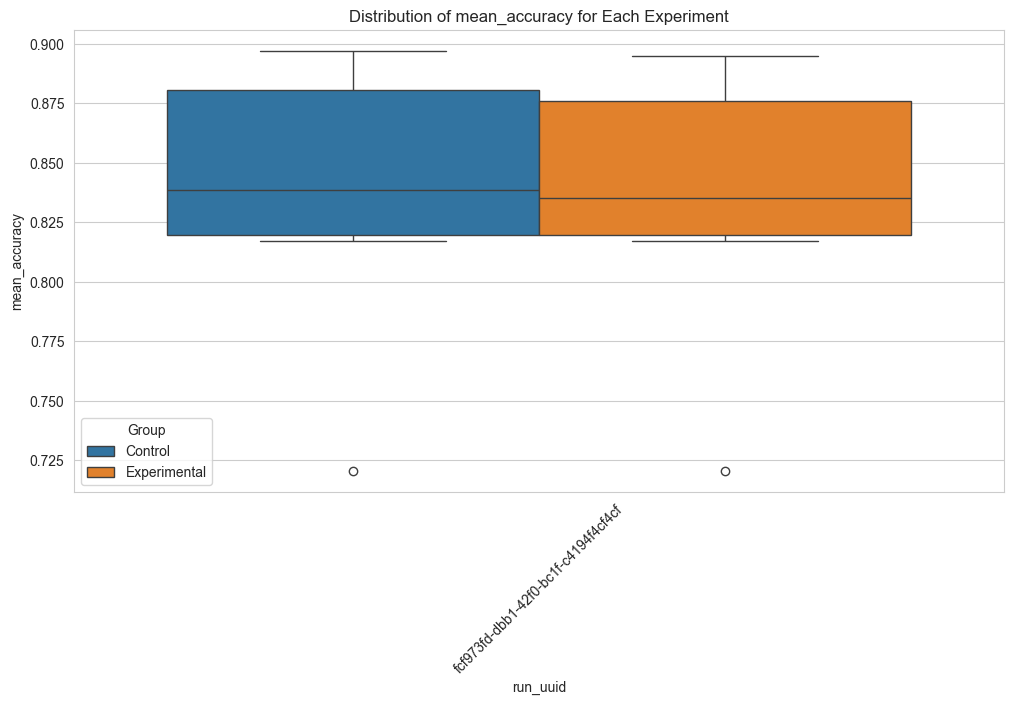

In [135]:

def plot_boxplots(df, metric):
    plt.figure(figsize=(12, 6))
    sns.boxplot(x="run_uuid", y=metric, hue="control_group", data=df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {metric} for Each Experiment")
    plt.legend(title="Group", labels=["Control", "Experimental"])
    plt.show()

# Example usage
plot_boxplots(df, "mean_accuracy")


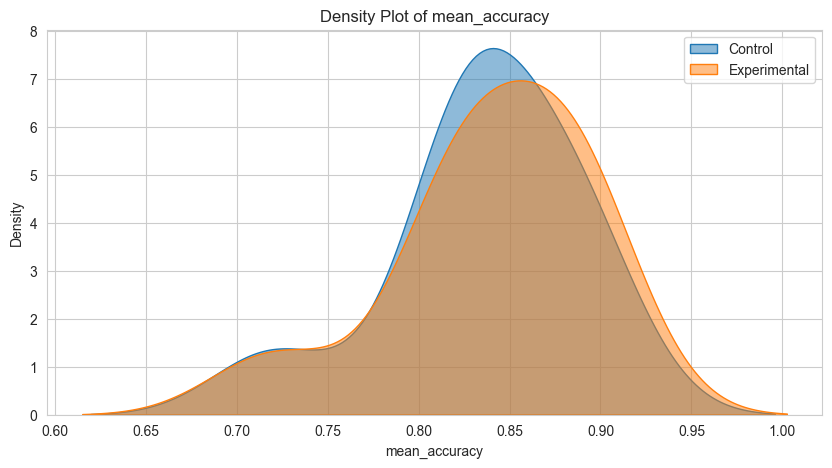

In [136]:
def plot_density(df, metric):
    plt.figure(figsize=(10, 5))
    sns.kdeplot(df[df["control_group"] == True][metric], fill=True, label="Control", alpha=0.5)
    sns.kdeplot(df[df["control_group"] == False][metric], fill=True, label="Experimental", alpha=0.5)
    plt.title(f"Density Plot of {metric}")
    plt.legend()
    plt.show()

# Example usage
plot_density(df, "mean_accuracy")


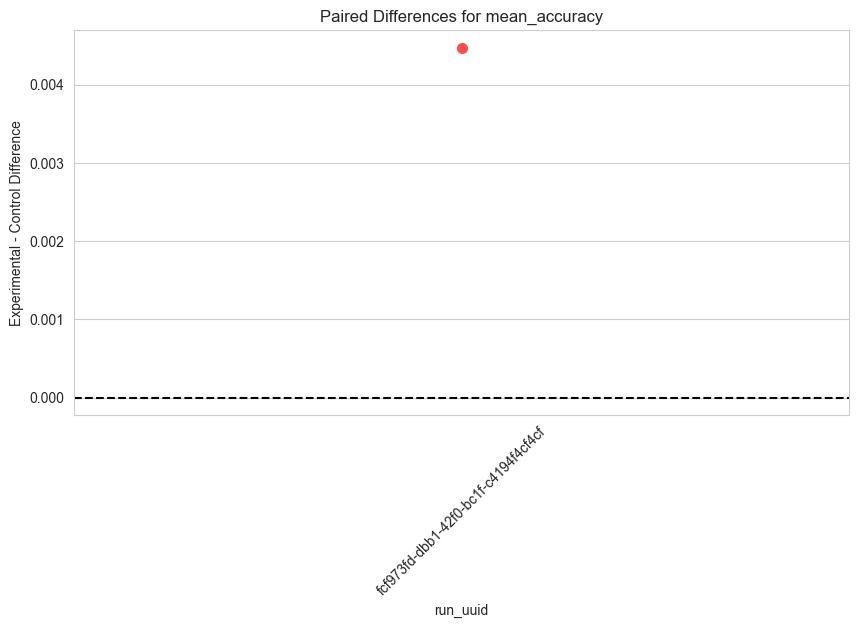

In [137]:
def plot_paired_differences(df, metric):
    plt.figure(figsize=(10, 5))

    # Compute mean difference per experiment
    diffs = df[df["control_group"] == False].groupby("run_uuid")[metric].mean() - \
            df[df["control_group"] == True].groupby("run_uuid")[metric].mean()

    sns.stripplot(x=diffs.index, y=diffs.values, color='red', alpha=0.7, size=8)
    plt.axhline(0, linestyle="--", color="black")

    plt.xticks(rotation=45)
    plt.ylabel("Experimental - Control Difference")
    plt.title(f"Paired Differences for {metric}")
    plt.show()

# Example usage
plot_paired_differences(df, "mean_accuracy")


In [138]:
# results = perform_wilcoxon(df)
df_pvalues = pd.DataFrame({
    "run_uuid": range(1, 31),
    "p_value": results["mean_accuracy"]["p_values"]  # Adjust metric
})
df_pvalues["significant"] = df_pvalues["p_value"] < 0.05

# Print summary
print(df_pvalues.describe())
print(f"Number of significant results: {df_pvalues['significant'].sum()} / 30")


KeyError: 'mean_accuracy'

In [139]:
def compute_effect_size(control, experimental):
    # Compute rank-biserial correlation (effect size for Wilcoxon test)
    return (experimental.mean() - control.mean()) / (experimental.std() + 1e-9)

effect_sizes = [
    compute_effect_size(
        df[(df["run_uuid"] == exp) & (df["control_group"] == True)]["mean_accuracy"],
        df[(df["run_uuid"] == exp) & (df["control_group"] == False)]["mean_accuracy"]
    )
    for exp in df["run_uuid"].unique()
]

df_pvalues["effect_size"] = effect_sizes
print(df_pvalues.sort_values("p_value"))


NameError: name 'df_pvalues' is not defined

In [140]:
from statsmodels.stats.multitest import multipletests

df_pvalues["p_adjusted"] = multipletests(df_pvalues["p_value"], method="fdr_bh")[1]
df_pvalues["significant_adjusted"] = df_pvalues["p_adjusted"] < 0.05

print(f"Significant after correction: {df_pvalues['significant_adjusted'].sum()} / 30")


NameError: name 'df_pvalues' is not defined

In [141]:


# def perform_wilcoxen(df, metrics=['mean_accuracy', 'var_accuracy', 'topographic_similarity']):
#     results = {}
#
#     for metric in metrics:
#         control = df.loc[df['control_group'] == True, metric]
#         experimental = df.loc[df['control_group'] == False, metric]
#
#         # t_stat, p_val = stats.ttest_ind(control, experimental)
#
#         stat, p_value = stats.wilcoxon(experimental, control)
#
#
#         results[metric] = {
#             'statistic': stat,
#             'p_value': p_value,
#             'control_mean': control.mean(),
#             'experimental_mean': experimental.mean(),
#             'control_std': control.std(),
#             'experimental_std': experimental.std()
#         }
#
#     return results

# def perform_wilcoxon(df, metrics=['mean_accuracy', 'var_accuracy', 'topographic_similarity']):
#     results = {}
#
#     for metric in metrics:
#         control = df.loc[df['control_group'] == True, metric].values
#         experimental = df.loc[df['control_group'] == False, metric].values
#
#         if len(control) != len(experimental):
#             raise ValueError(f"Wilcoxon requires paired samples but found {len(control)} and {len(experimental)}")
#
#         stat, p_value = scipy.stats.wilcoxon(control, experimental)
#
#         results[metric] = {
#             'statistic': stat,
#             'p_value': p_value,
#             'control_mean': control.mean(),
#             'experimental_mean': experimental.mean(),
#             'control_std': control.std(),
#             'experimental_std': experimental.std()
#         }
#
#     return results


print(json.dumps(perform_wilcoxen(df)))

NameError: name 'perform_wilcoxen' is not defined

In [142]:

def perform_variance_comparison(df, metrics=['mean_accuracy', 'var_accuracy', 'positional_disentanglement']):
    results = {}

    for metric in metrics:
        control = df[df['control_group'] == True][metric]
        experimental = df[df['control_group'] == False][metric]

        f_stat = np.var(control) / np.var(experimental)
        dfn = len(control) - 1
        dfd = len(experimental) - 1
        p_val = 2 * min(stats.f.cdf(f_stat, dfn, dfd),
                       1 - stats.f.cdf(f_stat, dfn, dfd))

        levene_stat, levene_p = stats.levene(control, experimental)

        results[metric] = {
            'f_statistic': f_stat,
            'f_test_p_value': p_val,
            'levene_statistic': levene_stat,
            'levene_p_value': levene_p,
            'control_variance': np.var(control),
            'experimental_variance': np.var(experimental),
            'variance_ratio': f_stat
        }

    return results


In [143]:

def create_plots(df, output_dir):
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)

    plt.style.use("seaborn-v0_8")

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x='full_epoch', y='mean_accuracy', hue='control_group', errorbar=('ci', 95))
    plt.title('Learning Curves: Mean Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Mean Accuracy')
    plt.savefig(output_dir / 'learning_curves.png')
    plt.close()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    sns.lineplot(data=df, x='full_epoch', y='message_entropy',
                hue='control_group', errorbar=('ci', 95), ax=ax1)
    ax1.set_title('Message Entropy over Epochs')

    sns.lineplot(data=df, x='full_epoch', y='vocab_usage',
                hue='control_group', errorbar=('ci', 95), ax=ax2)
    ax2.set_title('Vocabulary Usage over Epochs')

    plt.tight_layout()
    plt.savefig(output_dir / 'message_evolution.png')
    plt.close()

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 6), sharey=True)
    fig.suptitle("Accuracy Distributions", fontsize=24)
    sns.violinplot(data=df, x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax1)
    ax1.set_xticklabels(["experimental", "control"])
    ax1.set_title('Including common round 0 ').set_fontsize(20)
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax2)
    ax2.set_xticklabels(["experimental", "control"])
    ax2.set_title('Excluding common round 0 ').set_fontsize(20)
    ax2.set_ylabel('Accuracy')
    ax2.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 5], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax3)
    ax3.set_xticklabels(["experimental", "control"])
    ax3.set_title('After 5 rounds').set_fontsize(20)
    ax3.set_ylabel('Accuracy')
    ax3.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 8], x='control_group', y='mean_accuracy', common_norm=True, palette=["#81bb91", "#8aa5d3"], ax=ax4)
    ax4.set_xticklabels(["experimental", "control"])
    ax4.set_title('Final round').set_fontsize(20)
    ax4.set_ylabel('Accuracy')
    ax4.set_xlabel('Group')
    
    plt.tight_layout()
    plt.savefig(output_dir / 'accuracy_dist.png')
    plt.close()


    metrics = ['mean_accuracy', 'topographic_similarity',
               'positional_disentanglement']
    correlation = df[metrics].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
    plt.title('Correlation Matrix of Key Metrics')
    plt.tight_layout()
    plt.savefig(output_dir / 'correlation_matrix.png')
    plt.close()

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

    sns.violinplot(data=df, x='control_group', y='var_accuracy', ax=ax1)
    ax1.set_xticklabels(["experimental", "control"])
    ax1.set_title('Distribution of Variance in Accuracy including base round')
    ax1.set_ylabel('Variance')
    ax1.set_xlabel('Group')

    sns.violinplot(data=df.loc[df["round"] > 0], x='control_group', y='var_accuracy', ax=ax2)
    ax2.set_xticklabels(["experimental", "control"])
    ax2.set_title('Distribution of Variance in Accuracy excluding base round')
    ax2.set_ylabel('Variance')
    ax2.set_xlabel('Group')

    plt.tight_layout()
    plt.savefig(output_dir / 'variance_comparison.png')
    plt.close()

    plt.figure(figsize=(12, 6))
    for group in [True, False]:
        group_data = df[df['control_group'] == group]
        plt.fill_between(group_data['full_epoch'],
                        group_data['lb_accuracy'],
                        group_data['ub_accuracy'],
                        alpha=0.2)
        plt.plot(group_data['full_epoch'], group_data['mean_accuracy'],
                label=f'{"Control" if group else "Experimental"} Group')

    plt.title('Accuracy Evolution with Confidence Bands')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(output_dir / 'accuracy_evolution.png')
    plt.close()


In [144]:
from scipy import stats
# for some reason this additional import is required

input_path = ""
output_dir = ""

test_results = perform_wilcoxen(df)
with open(os.path.join(output_dir, 'test_results.json'), 'w') as f:
    json.dump(test_results, f, indent=4)

variance_results = perform_variance_comparison(df)
with open(os.path.join(output_dir, 'variance_comparison_results.json'), 'w') as f:
    json.dump(variance_results, f, indent=4)

create_plots(df, output_dir)

print("\nT-Test Results Summary:")
for metric, stats in test_results.items():
    print(f"\n{metric}:")
    print(f"statistic: {stats['statistic']}")
    print(f"p-value: {stats['p_value']}")
    print(f"Control group: mean={stats['control_mean']}, std={stats['control_std']}")
    print(f"Experimental group: mean={stats['experimental_mean']}, std={stats['experimental_std']}")

print("\nVariance Comparison Results:")
for metric, stats in variance_results.items():
    print(f"\n{metric}:")
    print(f"F-statistic: {stats['f_statistic']}")
    print(f"F-test p-value: {stats['f_test_p_value']}")
    print(f"Levene's test statistic: {stats['levene_statistic']}")
    print(f"Levene's test p-value: {stats['levene_p_value']}")
    print(f"Control group variance: {stats['control_variance']}")
    print(f"Experimental group variance: {stats['experimental_variance']}")
    print(f"Variance ratio (control/experimental): {stats['variance_ratio']}")

NameError: name 'perform_wilcoxen' is not defined

In [145]:
df_no_base_round = df.loc[df["round"] > 0]

In [146]:
from scipy import stats
# for some reason this additional import is required

input_path = ""
output_dir = "no_base_round"

os.makedirs(output_dir, exist_ok=True)

test_results = perform_wilcoxen(df_no_base_round)
with open(os.path.join(output_dir, 'test_results_without_base.json'), 'w') as f:
    json.dump(test_results, f, indent=4)

variance_results = perform_variance_comparison(df_no_base_round)
with open(os.path.join(output_dir, 'variance_comparison_results_without_base.json'), 'w') as f:
    json.dump(variance_results, f, indent=4)

create_plots(df_no_base_round, output_dir)

print("\nT-Test Results Summary:")
for metric, stats in test_results.items():
    print(f"\n{metric}:")
    print(f"t-statistic: {stats['statistic']}")
    print(f"p-value: {stats['p_value']}")
    print(f"Control group: mean={stats['control_mean']}, std={stats['control_std']}")
    print(f"Experimental group: mean={stats['experimental_mean']}, std={stats['experimental_std']}")

print("\nVariance Comparison Results:")
for metric, stats in variance_results.items():
    print(f"\n{metric}:")
    print(f"F-statistic: {stats['f_statistic']}")
    print(f"F-test p-value: {stats['f_test_p_value']}")
    print(f"Levene's test statistic: {stats['levene_statistic']}")
    print(f"Levene's test p-value: {stats['levene_p_value']}")
    print(f"Control group variance: {stats['control_variance']}")
    print(f"Experimental group variance: {stats['experimental_variance']}")
    print(f"Variance ratio (control/experimental): {stats['variance_ratio']}")

NameError: name 'perform_wilcoxen' is not defined

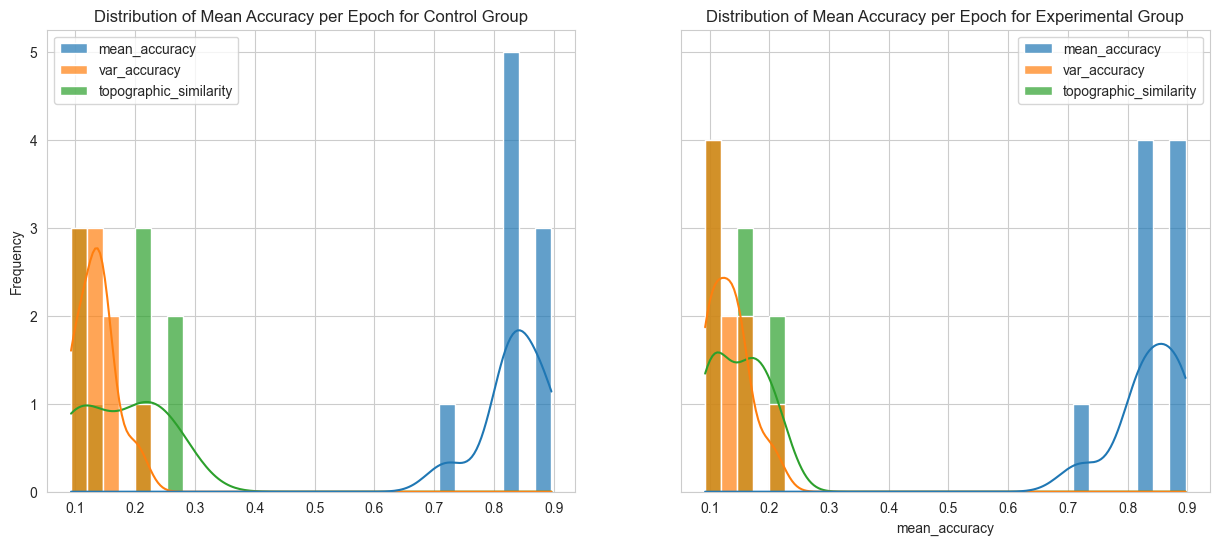

shapiro_stat mean of the accuracy control group: 0.864341828811611
p-value mean of the accuracy control group: 0.10686459817927102
shapiro_stat mean of the accuracy experiment group: 0.8603134070958973
p-value mean of the accuracy experiment group: 0.09663964298886757
shapiro_stat variance of the accuracy control group: 0.9042837866778862
p-value variance of the accuracy control group: 0.2778892290395156
shapiro_stat variance of the accuracy experiment group: 0.8988563957765884
p-value variance of the accuracy experiment group: 0.24544505952394924
shapiro_stat topographic similarity control group: 0.8867693300857912
p-value topographic similarity control group: 0.1847791591524222
shapiro_stat topographic similarity experiment group: 0.8779971212344507
p-value topographic similarity experiment group: 0.14956914230684681
shapiro_stat positional disentanglement control group: 0.8867693300857912
p-value positional disentanglement control group: 0.1847791591524222
shapiro_stat positional di

/Users/thomas/.pyenv/versions/3.10.12/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [147]:
from scipy import stats
# for some reason this additional import is required

mean_accuracy = df['mean_accuracy']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

sns.histplot(df.loc[df["control_group"] == True][["mean_accuracy", "var_accuracy", "topographic_similarity"]], kde=True, bins=30, alpha=0.7, ax=ax1)
ax1.set_title('Distribution of Mean Accuracy per Epoch for Control Group')
ax1.set_ylabel('Frequency')

sns.histplot(df.loc[df["control_group"] == False][["mean_accuracy", "var_accuracy", "topographic_similarity"]], kde=True, bins=30, alpha=0.7, ax=ax2)
ax2.set_title('Distribution of Mean Accuracy per Epoch for Experimental Group')
ax2.set_ylabel('Frequency')

plt.xlabel('mean_accuracy')

plt.grid(True)

plt.show()


shapiro_stat_mean_control, shapiro_p_value_mean_control = stats.shapiro(df.loc[df["control_group"] == True]["mean_accuracy"])
print(f"shapiro_stat mean of the accuracy control group: {shapiro_stat_mean_control}")
print(f"p-value mean of the accuracy control group: {shapiro_p_value_mean_control}")

shapiro_stat_mean, shapiro_p_value_mean = stats.shapiro(df.loc[df["control_group"] == False]["mean_accuracy"])
print(f"shapiro_stat mean of the accuracy experiment group: {shapiro_stat_mean}")
print(f"p-value mean of the accuracy experiment group: {shapiro_p_value_mean}")

shapiro_stat_variance_control, shapiro_p_value_variance_control = stats.shapiro(df.loc[df["control_group"] == True]["var_accuracy"])
print(f"shapiro_stat variance of the accuracy control group: {shapiro_stat_variance_control}")
print(f"p-value variance of the accuracy control group: {shapiro_p_value_variance_control}")

shapiro_stat_variance, shapiro_p_value_variance = stats.shapiro(df.loc[df["control_group"] == False]["var_accuracy"])
print(f"shapiro_stat variance of the accuracy experiment group: {shapiro_stat_variance}")
print(f"p-value variance of the accuracy experiment group: {shapiro_p_value_variance}")

shapiro_stat_topsim_control, shapiro_p_value_topsim_control = stats.shapiro(df.loc[df["control_group"] == True]["topographic_similarity"])
print(f"shapiro_stat topographic similarity control group: {shapiro_stat_topsim_control}")
print(f"p-value topographic similarity control group: {shapiro_p_value_topsim_control}")

shapiro_stat_topsim, shapiro_p_value_topsim = stats.shapiro(df.loc[df["control_group"] == False]["topographic_similarity"])
print(f"shapiro_stat topographic similarity experiment group: {shapiro_stat_topsim}")
print(f"p-value topographic similarity experiment group: {shapiro_p_value_topsim}")

shapiro_stat_posdis_control, shapiro_p_value_posdis_control = stats.shapiro(df.loc[df["control_group"] == True]["positional_disentanglement"])
print(f"shapiro_stat positional disentanglement control group: {shapiro_stat_topsim_control}")
print(f"p-value positional disentanglement control group: {shapiro_p_value_topsim_control}")

shapiro_stat_posdis, shapiro_p_value_posdis = stats.shapiro(df.loc[df["control_group"] == False]["positional_disentanglement"])
print(f"shapiro_stat positional disentanglement experiment group: {shapiro_stat_topsim}")
print(f"p-value positional disentanglement experiment group: {shapiro_p_value_topsim}")



def create_latex_table(results_dict):
    latex_code = [
        "\\begin{table}[h]",
        "\\centering",
        "\\begin{tabular}{lccc}",
        "\\toprule",
        "Metric & Group & Statistic & p-value \\\\",
        "\\midrule"
    ]

    for metric in ["Mean Accuracy", "Variance Accuracy", "Topographic Similarity"]:
        for group in ["Control", "Experiment"]:
            stat_key = f"{metric.lower().replace(' ', '_')}_{group.lower()}_stat"
            p_key = f"{metric.lower().replace(' ', '_')}_{group.lower()}_p"

            row = f"{metric} & {group} & {results_dict[stat_key]} & {results_dict[p_key]} \\\\"
            latex_code.append(row)

        if metric != "Positional Disentanglement":
            latex_code.append("\\midrule")

    latex_code.extend([
        "\\bottomrule",
        "\\end{tabular}",
        "\\caption{Shapiro-Wilk Test Results for Normality}",
        "\\label{tab:shapiro_results}",
        "\\end{table}"
    ])

    return "\n".join(latex_code)

results = {
    "mean_accuracy_control_stat": shapiro_stat_mean_control,
    "mean_accuracy_control_p": shapiro_p_value_mean_control,
    "mean_accuracy_experiment_stat": shapiro_stat_mean,
    "mean_accuracy_experiment_p": shapiro_p_value_mean,
    "variance_accuracy_control_stat": shapiro_stat_variance_control,
    "variance_accuracy_control_p": shapiro_p_value_variance_control,
    "variance_accuracy_experiment_stat": shapiro_stat_variance,
    "variance_accuracy_experiment_p": shapiro_p_value_variance,
    "topographic_similarity_control_stat": shapiro_stat_topsim_control,
    "topographic_similarity_control_p": shapiro_p_value_topsim_control,
    "topographic_similarity_experiment_stat": shapiro_stat_topsim,
    "topographic_similarity_experiment_p": shapiro_p_value_topsim
}

print(create_latex_table(results))


In [148]:
def create_latex_table_wilcoxon(results_dict):
    latex_code = [
        "\\begin{table}[h]",
        "\\centering",
        "\\begin{tabular}{lcccc}",
        "\\toprule",
        "Metric & Control Mean & Experimental Mean & Statistic & p-value \\\\",
        "\\midrule"
    ]

    for metric in results_dict.keys():
        control_mean = results_dict[metric]["control_mean"]
        experimental_mean = results_dict[metric]["experimental_mean"]
        statistic = results_dict[metric]["statistic"]
        p_value = results_dict[metric]["p_value"]
        
        row = f"{metric.replace('_', ' ').title()} & {control_mean} & {experimental_mean} & {statistic} & {p_value} \\\\"
        latex_code.append(row)

    latex_code.extend([
        "\\bottomrule",
        "\\end{tabular}",
        "\\caption{Wilcoxon Test Results}",
        "\\label{tab:wilcoxon_results}",
        "\\end{table}"
    ])

    return "\n".join(latex_code)



In [149]:
print(create_latex_table_wilcoxon(perform_wilcoxen(df, ["mean_accuracy", "var_accuracy", "topographic_similarity"])))


NameError: name 'perform_wilcoxen' is not defined

In [150]:
def plot_hypothesis_test(results_dict, metric_label_map=None):
    plot_data = []
    for metric, values in results_dict.items():
        label = metric_label_map[metric] if metric_label_map else metric.replace("_", " ").title()
        plot_data.append({
            "Metric": label,
            "Group": "Control",
            "Mean": values["control_mean"],
            "Std": values["control_std"]
        })
        plot_data.append({
            "Metric": label,
            "Group": "Experimental",
            "Mean": values["experimental_mean"],
            "Std": values["experimental_std"]
        })

    df_plot = pd.DataFrame(plot_data)

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=df_plot,
        x="Metric",
        y="Mean",
        hue="Group",
        palette="muted",
        ci=None
    )

    for i, (metric, values) in enumerate(results_dict.items()):
        control_mean = values["control_mean"]
        experimental_mean = values["experimental_mean"]
        control_std = values["control_std"]
        experimental_std = values["experimental_std"]
        p_value = values["p_value"]
        stat = values["statistic"]

        ax.errorbar(
            x=i - 0.2,
            y=control_mean,
            yerr=control_std,
            fmt='none',
            capsize=5,
            color='black'
        )
        ax.errorbar(
            x=i + 0.2,
            y=experimental_mean,
            yerr=experimental_std,
            fmt='none',
            capsize=5,
            color='black'
        )

        ax.text(
            x=i, y=max(control_mean, experimental_mean) + 0.02,
            s=f"p={p_value:.3f}, W={stat:.2f}",
            ha="center",
            fontsize=10,
            color="black"
        )

    plt.title("Hypothesis Test Results")
    plt.ylabel("Mean Value")
    plt.xlabel("Metric")
    plt.legend(title="Group")
    plt.tight_layout()
    plt.show()


In [151]:
def plot_hypothesis_test_context(df, results_dict, metrics, alpha=0.05):
    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(6 * num_metrics, 6), sharey=True)

    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        control = df.loc[df['control_group'] == True, metric]
        experimental = df.loc[df['control_group'] == False, metric]

        plot_data = pd.concat([
            pd.DataFrame({metric: control, "Group": "Control"}),
            pd.DataFrame({metric: experimental, "Group": "Experimental"})
        ])

        sns.swarmplot(data=plot_data, x="Group", y=metric, ax=ax, color="black", alpha=0.7)

        sns.barplot(
            data=plot_data, x="Group", y=metric, ax=ax,
            ci="sd", capsize=0.2, palette="muted", alpha=0.8
        )

        stat = results_dict[metric]["statistic"]
        p_value = results_dict[metric]["p_value"]
        y_max = max(control.max(), experimental.max())

        ax.text(
            x=0.5, y=y_max + 0.05 * y_max,
            s=f"p={p_value:.3f}, W={stat:.2f}",
            ha="center", fontsize=12, color="red" if p_value < alpha else "blue"
        )

        ax.axhline(y=alpha, color="gray", linestyle="--", linewidth=1, label=f"α={alpha}")

        ax.set_title(f"{metric.replace('_', ' ').title()}", fontsize=14)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Group", fontsize=12)

    plt.suptitle("Hypothesis Test Results in Context of Experiment", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/462568988.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/462568988.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/462568988.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False`

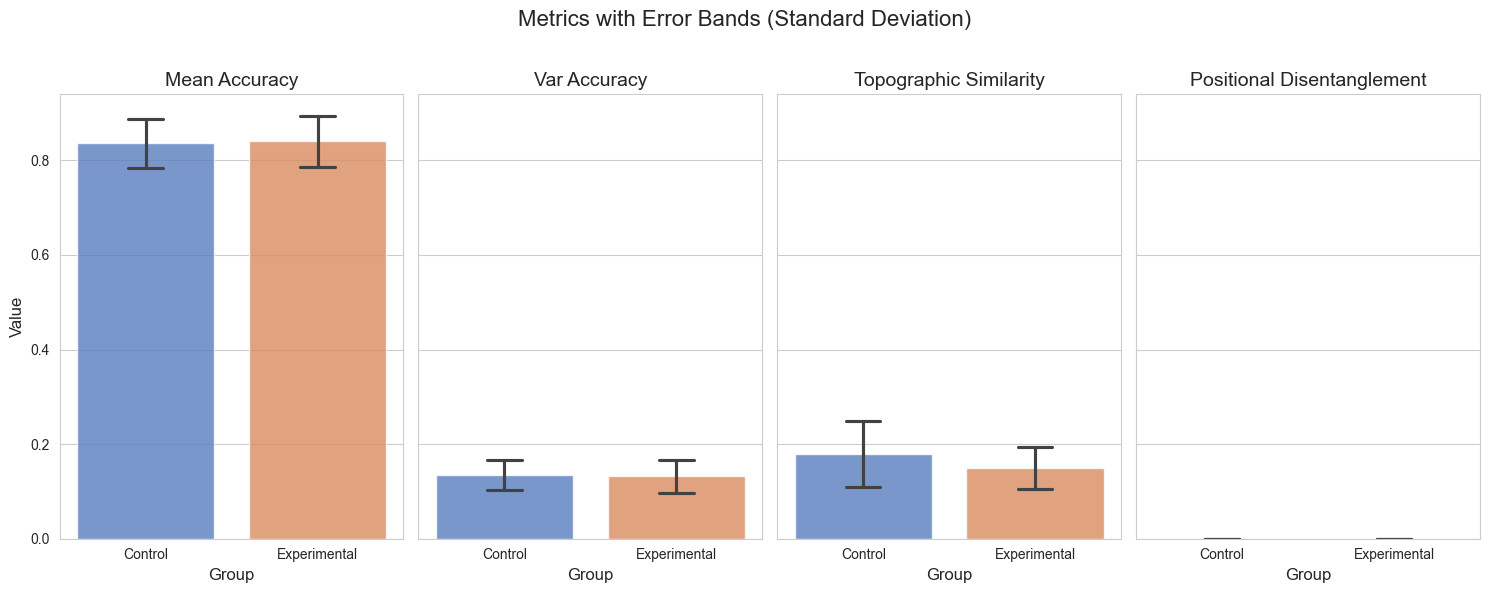

In [152]:
def plot_metrics_with_error_bands(df, metrics):

    num_metrics = len(metrics)
    fig, axes = plt.subplots(1, num_metrics, figsize=(15, 6), sharey=True)

    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        plot_data = pd.concat([
            pd.DataFrame({metric: df.loc[df['control_group'] == True, metric], "Group": "Control"}),
            pd.DataFrame({metric: df.loc[df['control_group'] == False, metric], "Group": "Experimental"})
        ])

        sns.barplot(data=plot_data, x="Group", y=metric, ax=ax, errorbar="sd", capsize=0.2, palette="muted", alpha=0.8)

        ax.set_title(f"{metric.replace('_', ' ').title()}", fontsize=14)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Group", fontsize=12)

    plt.suptitle("Metrics with Error Bands (Standard Deviation)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

metrics = ['mean_accuracy', 'var_accuracy', 'topographic_similarity', 'positional_disentanglement']

plot_metrics_with_error_bands(df, metrics)


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/334856528.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/334856528.py:22: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


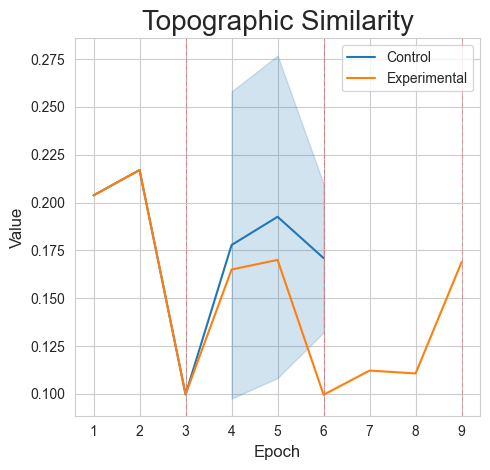

In [153]:
def plot_metrics_with_error_bands(df, metrics):
    num_metrics = len(metrics)
    plots_per_row = 3
    num_rows = math.ceil(num_metrics / plots_per_row)
    num_cols = min(num_metrics, plots_per_row)  # Ensure it adapts to num_metrics

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))

    if num_metrics == 1:
        axes = [axes]
    elif num_metrics > 1:
        axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.lineplot(
            data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', errorbar=("ci", 95), palette=["#8aa5d3", "#81bb91"],
            estimator='median'
        )

        sns.lineplot(
            data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', errorbar=("ci", 95), palette=["#8aa5d3", "#81bb91"],
            estimator='median'
        )

        for _, row in df.iterrows():
            if row["full_epoch"] % row["epochs_per_round"] == 0:
                ax.axvline(x=row["full_epoch"], linestyle='-.', label=f"round {row['full_epoch']}", lw=0.5, color="#cf7c81")

        ax.set_title(f"{metric.replace('_', ' ').replace('var', 'Variance').title()}", fontsize=20)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Epoch", fontsize=12)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# metrics = ['mean_accuracy', 'var_accuracy', 'topographic_similarity']
# metrics = ['mean_accuracy', 'topographic_similarity']
# metrics = ['mean_accuracy']
metrics = ['topographic_similarity']

plot_metrics_with_error_bands(df, metrics)


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/3644090574.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/3644090574.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/3644090574.py:17: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_49161/3644090574.py:21: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


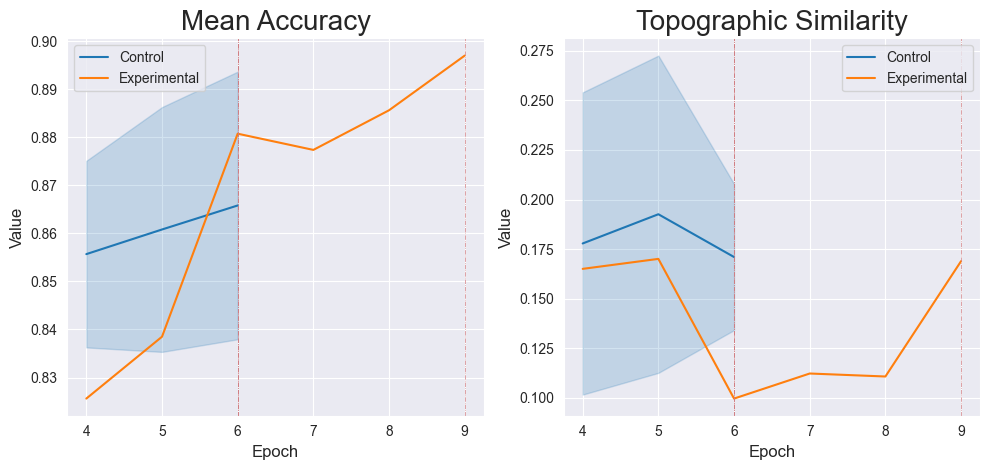

In [113]:
def plot_metrics_with_error_bands(df, metrics):
    num_metrics = len(metrics)
    plots_per_row = 3
    num_rows = (num_metrics + plots_per_row - 1) // plots_per_row
    num_cols = math.ceil(num_metrics / num_rows)

    fig, axes = plt.subplots(num_rows, min(plots_per_row, num_cols), figsize=(5*num_cols, 5*num_rows))
    axes = axes.flatten()


    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        sns.lineplot(
            data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        )

        sns.lineplot(
            data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        )
        
        
    
        for i, row in df.iterrows():
            if row["full_epoch"] % row["epochs_per_round"] == 0:
                ax.axvline(x=row["full_epoch"], linestyle='-.', label=f"round {round}", lw=0.5, color="#cf7c81")

        ax.set_title(f"{metric.replace('_', ' ').replace('var', 'Variance').title()}", fontsize=20)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Epoch", fontsize=12)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

metrics = ['mean_accuracy', 'topographic_similarity']

plot_metrics_with_error_bands(df.loc[df["round"] > 0], metrics)


hallooo


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_99617/3422202659.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_99617/3422202659.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_99617/3422202659.py:29: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_99617/3422202659.py:33: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


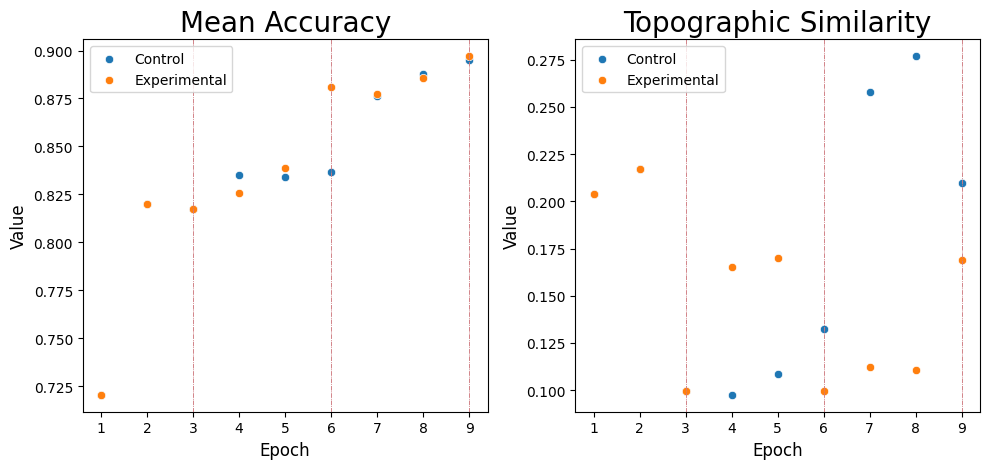

In [44]:
def plot_metrics_with_error_bands(df, metrics):

    num_metrics = len(metrics)
    plots_per_row = 3
    num_rows = (num_metrics + plots_per_row - 1) // plots_per_row
    num_cols = math.ceil(num_metrics / num_rows)
    
    
    fig, axes = plt.subplots(num_rows, min(plots_per_row, num_cols), figsize=(5*num_cols, 5*num_rows))
    axes = axes.flatten()



    if num_metrics == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # sns.lineplot(
        #     data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        # )
        # 
        # sns.lineplot(
        #     data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', errorbar=("pi", 95), palette=["#8aa5d3", "#81bb91"]
        # )
        
        
        sns.scatterplot(
            data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', palette=["#8aa5d3", "#81bb91"]
        )

        sns.scatterplot(
            data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', palette=["#8aa5d3", "#81bb91"]
        )
    
        for i, row in df.iterrows():
            if row["full_epoch"] % row["epochs_per_round"] == 0:
                ax.axvline(x=row["full_epoch"], linestyle='-.', label=f"round {round}", lw=0.5, color="#cf7c81")

        ax.set_title(f"{metric.replace('_', ' ').replace('var', 'Variance').title()}", fontsize=20)
        ax.set_ylabel("Value", fontsize=12)
        ax.set_xlabel("Epoch", fontsize=12)
    
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

metrics = ['mean_accuracy', 'topographic_similarity']
print("hallooo")
for run in df["run_uuid"].unique():
    plot_metrics_with_error_bands(df.loc[df["run_uuid"] == run], metrics)


ValueError: supplied range of [nan, nan] is not finite

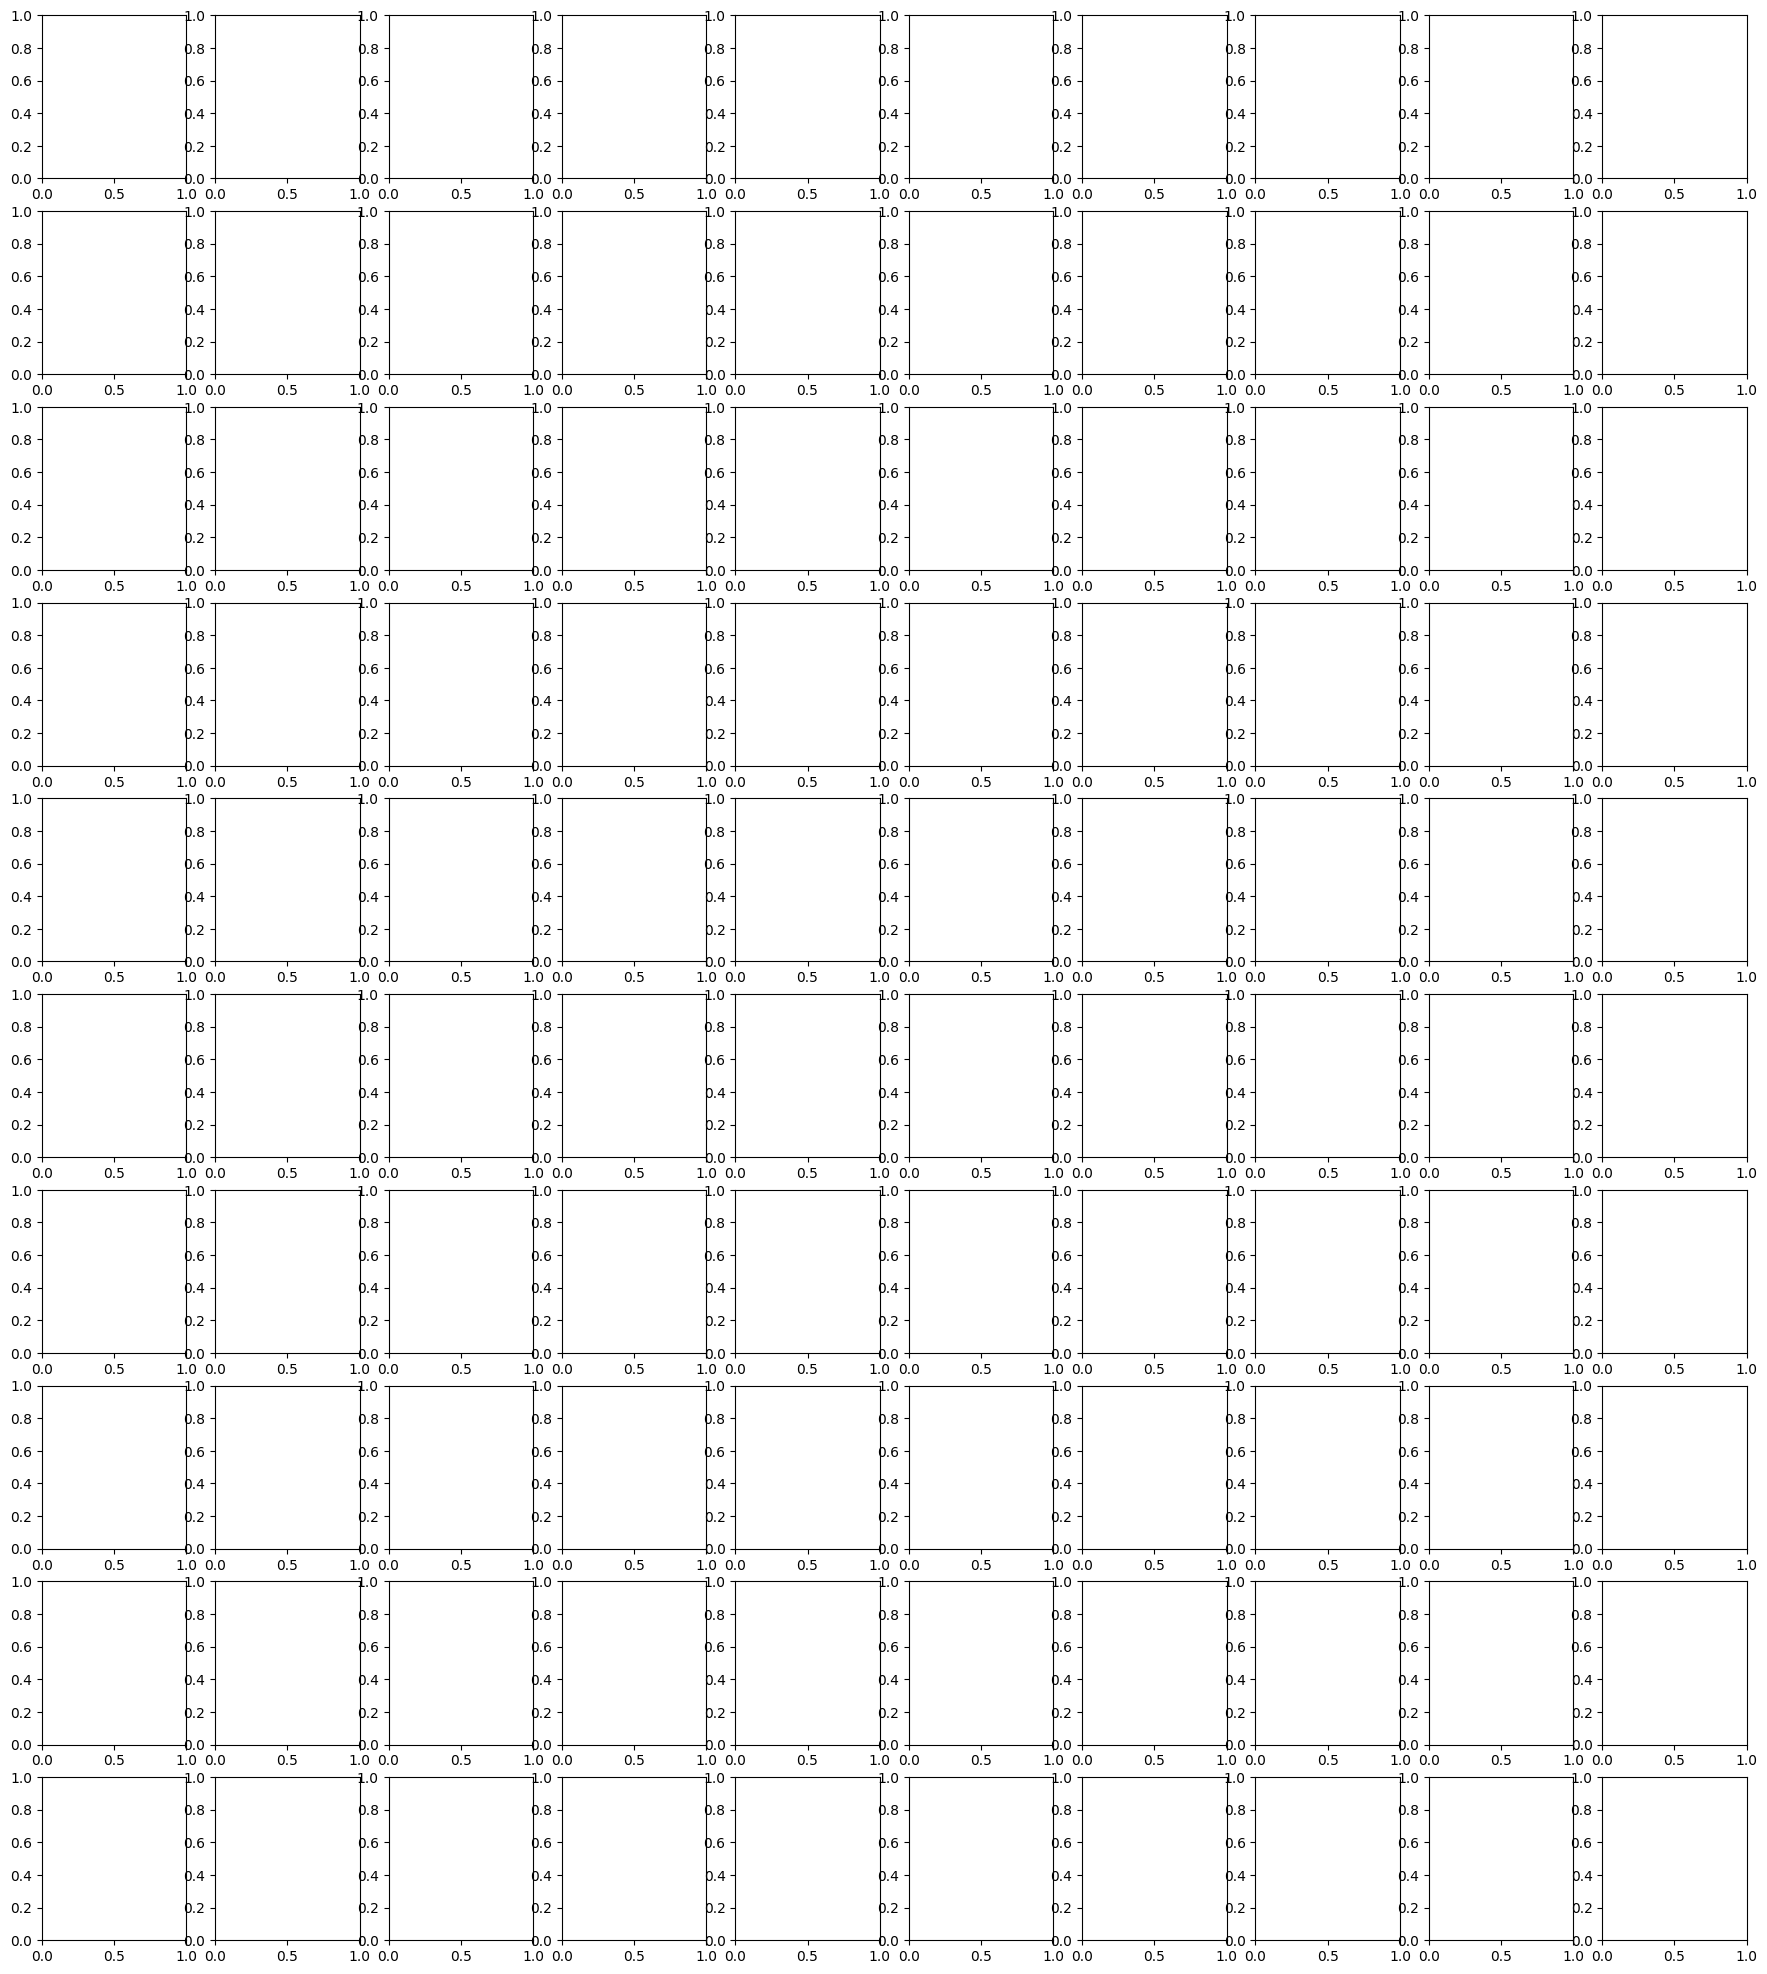

In [19]:
fig, axes = plt.subplots(10, 10, figsize=(22, 25))

palette = ["#8aa5d3", "#81bb91"]

x_min, x_max = df["mean_accuracy"].min(), df["mean_accuracy"].max()
y_max = 0

for i in range(0, 100):
    for group in [True, False]:
        subset = df[(df["control_group"] == group) & (df["full_epoch"] == i + 1)]
        if not subset.empty:
            counts, _ = np.histogram(subset["mean_accuracy"], bins="auto", range=(x_min, x_max))
            y_max = max(y_max, counts.max())

for i in range(0, 100):
    row, col = divmod(i, 10)
    ax = axes[row, col]

    for group, color in zip([True, False], palette):
        subset = df[(df["control_group"] == group) & (df["full_epoch"] == i + 1)]

        ax.hist(subset["mean_accuracy"], bins=15, alpha=0.5, color=color, label=f'Group {group}', range=(x_min, x_max))

    ax.set_title(f'Epoch {i+1}', fontsize=8)
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, y_max)
    ax.set_xticks(np.linspace(math.floor(x_min * 10) / 10, math.ceil(x_max * 10) / 10, 3))
    ax.set_yticks(np.linspace(0, math.ceil((y_max + 1) * 10) / 10, 5))

for row in range(10):
    fig.text(
        -0.01,
        1 - (row + 0.5) / 10,
        f"Round {row + 1}",
        ha="center",
        va="center",
        rotation="vertical",
        fontsize=10,
        fontweight="bold"
    )

handles = [
    plt.Line2D([0], [0], color=palette[0], lw=4, label='Control Group = True'),
    plt.Line2D([0], [0], color=palette[1], lw=4, label='Control Group = False')
]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, -0.01))

plt.tight_layout(rect=[0.01, 0.01, 1, 1])

plt.show()


In [116]:
def csv_to_latex_table(csv_file, output_file=None, caption=None, label=None, index=False, columns=None, exclude_columns=None):
    df = pd.read_csv(csv_file)

    if columns:
        df = df[columns]

    if exclude_columns:
        df = df.drop(columns=exclude_columns)

    latex_table = df.to_latex(index=index, escape=False)

    if caption or label:
        lines = latex_table.splitlines()
        if caption:
            lines.insert(1, f"\\caption{{{caption}}}")
        if label:
            lines.insert(2 if caption else 1, f"\\label{{{label}}}")
        latex_table = "\n".join(lines)

    if output_file:
        with open(output_file, 'w') as f:
            f.write(latex_table)
    else:
        return latex_table


In [117]:
# plot nr of epochs until crossing control group

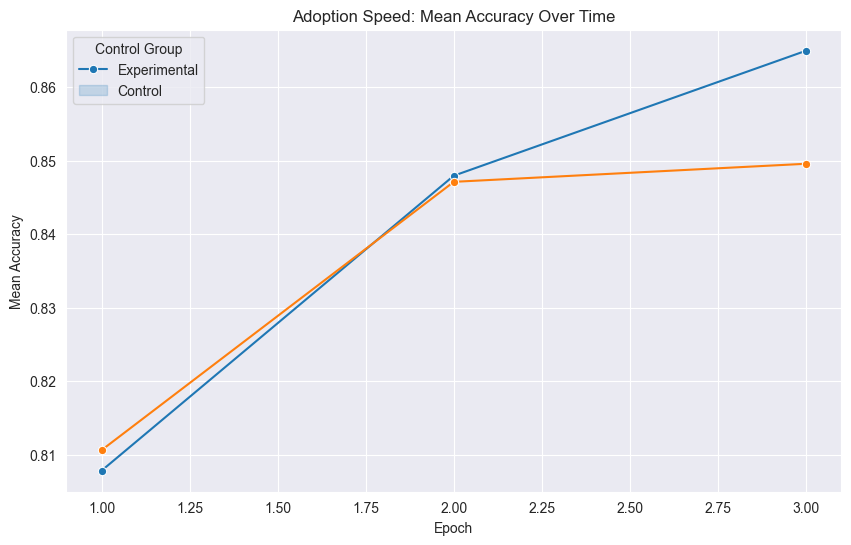

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert control_group to a boolean
df["control_group"] = df["control_group"].astype(bool)

# Aggregate mean accuracy per epoch for both groups
df_grouped = df.groupby(["epoch", "control_group"])["mean_accuracy"].mean().reset_index()

# Plot accuracy over epochs
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_grouped, x="epoch", y="mean_accuracy", hue="control_group", marker="o")

plt.xlabel("Epoch")
plt.ylabel("Mean Accuracy")
plt.title("Adoption Speed: Mean Accuracy Over Time")
plt.legend(title="Control Group", labels=["Experimental", "Control"])
plt.grid(True)
plt.show()


In [119]:
df


# df["group"] = df["control_group"].map({True: "Control", False: "Treatment"})

# Pivot table to compare accuracy over time for each (experiment, round)
# df_pivot = df.pivot(index=['experiment_uuid', 'round', 'full_epoch'], columns='group', values='mean_accuracy')
# df

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp,experiment_uuid,full_epoch,completed
0,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,1,3,[1. 1. 1. ... 1. 1. 1.],0.720500,1.600057,-0.159057,0.448754,0.201380,...,0.720482,1.070864,1.146750,22555.000305,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:04.047153,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,1,True
1,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,2,3,[1. 1. 1. ... 1. 1. 0.],0.819750,1.573165,0.066335,0.384396,0.147760,...,0.719647,1.081621,1.169905,22716.999054,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:21.969439,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,2,True
2,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,3,3,[0. 1. 1. ... 1. 1. 0.],0.817125,1.574790,0.059460,0.386564,0.149432,...,0.672192,1.119353,1.252952,22929.000854,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:40.667887,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,3,True
3,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,1,3,[1. 1. 1. ... 1. 1. 1.],0.720500,1.600057,-0.159057,0.448754,0.201380,...,0.720482,1.070864,1.146750,22555.000305,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:04.047153,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,1,True
5,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,2,3,[1. 1. 1. ... 1. 1. 0.],0.819750,1.573165,0.066335,0.384396,0.147760,...,0.719647,1.081621,1.169905,22716.999054,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:21.969439,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,2,True
7,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,0,3,3,[0. 1. 1. ... 1. 1. 0.],0.817125,1.574790,0.059460,0.386564,0.149432,...,0.672192,1.119353,1.252952,22929.000854,True,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:40.667887,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,3,True
9,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,1,3,[1. 1. 1. ... 1. 1. 1.],0.825625,1.569311,0.081939,0.379432,0.143968,...,0.630799,1.033649,1.068429,21253.999710,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:43:58.630382,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,4,True
10,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,2,3,[1. 1. 1. ... 1. 1. 1.],0.838500,1.559763,0.117237,0.367992,0.135418,...,0.607451,1.045369,1.092797,21250.999451,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:16.654605,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,5,True
11,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,1,3,3,[1. 1. 1. ... 1. 1. 1.],0.880750,1.515952,0.245548,0.324082,0.105029,...,0.576187,1.049330,1.101094,21062.999725,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:34.251545,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,6,True
12,fcf973fd-dbb1-42f0-bc1f-c4194f4cf4cf,2,1,3,[1. 1. 1. ... 1. 1. 1.],0.877375,1.520267,0.234483,0.328006,0.107588,...,0.619011,1.043362,1.088604,21312.000275,False,"Namespace(rounds=3, dev=False, prod=True, n_di...",2025-04-27 21:44:51.692443,2025_04_27_7d0b3fce-faab-40de-8588-17e63a8a7048,7,True


In [120]:
df_control = df.loc[df["control_group"] == True]
df_experiment = df.loc[df["control_group"] == False]

# Set seaborn style
sns.set_style("whitegrid")

# Convert boolean control_group column to labels
df["group"] = df["control_group"].map({True: "Control", False: "Treatment"})

# Pivot table to compare accuracy over time for each (run_uuid, round)
df_pivot = df.pivot(index=['run_uuid', 'round', 'epoch'], columns='group', values='mean_accuracy')

# Find the first full_epoch where Treatment > Control in each (run_uuid, round)
def first_overtake_epoch(sub_df):
    overtake = (sub_df['Treatment'] > sub_df['Control'])
    if overtake.any():
        return sub_df.index[overtake][0][2]  # Extract the full_epoch (the third element of the tuple)
    return np.nan  # If no overtake happens

overtake_epochs = df_pivot.groupby(level=['run_uuid', 'round']).apply(first_overtake_epoch).dropna()

# Plot 1: Distribution of Overtake Epochs (Across Rounds)
plt.figure(figsize=(8, 5))
sns.histplot(overtake_epochs, bins=30, kde=True, hue="round")
plt.xlabel("Full Epoch of First Overtake")
plt.ylabel("Frequency")
plt.title("Distribution of Overtake Epochs (Across Rounds)")
plt.show()

# Survival analysis (Kaplan-Meier curve for overtaking per round)
event_occurred = ~overtake_epochs.isna()
event_time = overtake_epochs
              # .fillna(df['epoch'].max()))  # If no event, use max epoch

kmf = KaplanMeierFitter()
kmf.fit(event_time, event_observed=event_occurred)

# Plot 2: Kaplan-Meier Survival Curve (Per Round)
plt.figure(figsize=(8, 5))
kmf.plot_survival_function()
plt.xlabel("Full Epoch")
plt.ylabel("Probability of Not Overtaking")
plt.title("Kaplan-Meier Survival Curve for Overtaking (Per Round)")
plt.show()

# Compute slopes for Treatment and Control per (run_uuid, round)
def compute_slope(sub_df):
    # Ensure that the 'full_epoch' and 'mean_accuracy' are numeric and non-NaN
    sub_df = sub_df.dropna(subset=["full_epoch", "mean_accuracy"])  # Drop any rows with NaN values
    return linregress(sub_df['full_epoch'], sub_df['mean_accuracy']).slope

slopes = df.groupby(['run_uuid', 'round', 'group']).apply(compute_slope).unstack()

# Plot 3: Distribution of Accuracy Improvement Slopes (Per Round)
plt.figure(figsize=(8, 5))
sns.histplot(slopes['Treatment'], bins=15, color="green", label="Treatment", kde=True, alpha=0.6)
sns.histplot(slopes['Control'], bins=15, color="red", label="Control", kde=True, alpha=0.6)
plt.xlabel("Accuracy Improvement Rate (Slope)")
plt.ylabel("Frequency")
plt.title("Distribution of Accuracy Improvement Slopes (Per Round)")
plt.legend()
plt.show()

# Plot 4: Accuracy Progression for Sample Rounds
sample_runs = np.random.choice(df['run_uuid'].unique(), size=3, replace=False)
sample_rounds = np.random.choice(df['round'].unique(), size=3, replace=False)
df_sample = df[(df['run_uuid'].isin(sample_runs)) & (df['round'].isin(sample_rounds))]

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_sample, x="full_epoch", y="mean_accuracy", hue="group", style="round", markers=True)
plt.xlabel("Full Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Progression Over Time (Sample Rounds)")
plt.show()



ValueError: The following variable cannot be assigned with wide-form data: `hue`

<Figure size 800x500 with 0 Axes>

In [43]:
df.loc[df["control_group"] == True]

,run_uuid,round,epoch,epochs_per_round,accuracy,mean_accuracy,ub_accuracy,lb_accuracy,std_accuracy,var_accuracy,...,lb_message_length,std_message_length,var_message_length,var_bern_message_length,control_group,params,timestamp,experiment_uuid,full_epoch,completed
10,d15f2c08-8d2b-4753-bbb6-ab0024649e76,0,1,10,[1. 1. 1. ... 1. 0. 0.],0.723000,1.600132,-0.154132,0.447516,0.200271,...,2.696884,0.573018,0.328350,30559.999466,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-23 21:48:17.658795,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,1,True
12,d15f2c08-8d2b-4753-bbb6-ab0024649e76,0,2,10,[0. 1. 1. ... 1. 1. 0.],0.808125,1.579925,0.036325,0.393775,0.155059,...,4.000000,0.000000,0.000000,32000.000000,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-23 21:48:36.122216,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,2,True
14,d15f2c08-8d2b-4753-bbb6-ab0024649e76,0,3,10,[1. 1. 1. ... 1. 1. 1.],0.923250,1.444991,0.401509,0.266194,0.070859,...,4.000000,0.000000,0.000000,32000.000000,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-23 21:48:54.146089,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,3,True
16,d15f2c08-8d2b-4753-bbb6-ab0024649e76,0,4,10,[1. 1. 1. ... 1. 1. 1.],0.934375,1.419721,0.449029,0.247625,0.061318,...,4.000000,0.000000,0.000000,32000.000000,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-23 21:49:12.266603,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,4,True
18,d15f2c08-8d2b-4753-bbb6-ab0024649e76,0,5,10,[1. 1. 1. ... 1. 1. 1.],0.917750,1.456251,0.379249,0.274745,0.075485,...,4.000000,0.000000,0.000000,32000.000000,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-23 21:49:30.316278,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,5,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1045,3c51c3aa-4e57-4f2f-be28-cd7544a9a505,9,6,10,[1. 1. 1. ... 1. 1. 1.],0.960500,1.342271,0.578729,0.194781,0.037940,...,1.827627,0.939603,0.882855,29354.000092,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-24 02:47:27.620183,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,16,True
1046,3c51c3aa-4e57-4f2f-be28-cd7544a9a505,9,7,10,[1. 1. 1. ... 1. 1. 1.],0.959750,1.344978,0.574522,0.196545,0.038630,...,1.837969,0.935858,0.875830,29378.000259,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-24 02:47:47.313160,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,17,True
1047,3c51c3aa-4e57-4f2f-be28-cd7544a9a505,9,8,10,[1. 1. 0. ... 1. 1. 1.],0.957125,1.354173,0.560077,0.202575,0.041037,...,1.837969,0.935858,0.875830,29378.000259,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-24 02:48:07.136737,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,18,True
1048,3c51c3aa-4e57-4f2f-be28-cd7544a9a505,9,9,10,[1. 1. 1. ... 1. 1. 1.],0.952125,1.370588,0.533662,0.213502,0.045583,...,1.844456,0.933504,0.871430,29392.999649,True,"Namespace(rounds=10, dev=False, prod=True, n_d...",2025-04-24 02:48:26.919437,2025_04_23_7d0b3fce-faab-40de-8588-17e63a8a7048,19,True


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df["group"] = df["control_group"].map({True: "Control", False: "Treatment"})

# Pivot table to compare accuracy over time for each (run_uuid, round)
df_pivot = df.pivot(index=['run_uuid', 'round', 'full_epoch'], columns='group', values='mean_accuracy')

# Find the first full_epoch where Treatment > Control in each (run_uuid, round)
def first_overtake_epoch(sub_df):
    overtake = (sub_df['Treatment'] > sub_df['Control'])
    if overtake.any():
        # print(sub_df.index[overtake])
        return sub_df.index[overtake][0][2]  # Extract the full_epoch (the third element of the tuple)
    return np.nan  # If no overtake happens


overtake_epochs = df_pivot.groupby(level=['run_uuid', 'round']).apply(first_overtake_epoch).dropna()
# normalize epochs:

overtake_epochs['norm_epoch'] = overtake_epochs['full_epoch'] - overtake_epochs["round"] * full_experiment_df["epochs_per_round"]

print(overtake_epochs)

# Convert to DataFrame for plotting
overtake_epochs_df = overtake_epochs.reset_index()
overtake_epochs_df.columns = ['run_uuid', 'round', 'overtake_epoch']

# Ensure 'round' is an integer for sorting
overtake_epochs_df['round'] = overtake_epochs_df['round'].astype(int)

# Get all rounds and sort them
unique_rounds = sorted(overtake_epochs_df['round'].unique())



# Create separate plots per round
fig, axes = plt.subplots(len(unique_rounds), 1, figsize=(8, 4 * len(unique_rounds)), sharex=True)

# Ensure axes is always iterable (even if there's only one round)
if len(unique_rounds) == 1:
    axes = [axes]

for ax, round_num in zip(axes, unique_rounds):
    round_data = overtake_epochs_df[overtake_epochs_df['round'] == round_num]

    if round_data.empty:
        print(f"Warning: No data for round {round_num}, skipping plot.")
        continue  # Skip empty rounds

    sns.histplot(
        data=round_data,
        x="overtake_epoch",
        bins=20,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Round {round_num}")
    ax.set_xlabel("Full Epoch of First Overtake")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


KeyError: 'full_epoch'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct mapping
df["group"] = df["control_group"].map({True: "Control", False: "Treatment"})

# Pivot table
df_pivot = df.pivot(index=['run_uuid', 'round', 'full_epoch'], columns='group', values='mean_accuracy')

# Function to find first overtake epoch
def first_overtake_epoch(sub_df):
    overtake = (sub_df['Treatment'] > sub_df['Control'])
    if overtake.any():
        return sub_df.index[overtake][0][2]  # Extract full_epoch
    return np.nan

overtake_epochs = df_pivot.groupby(level=['run_uuid', 'round']).apply(first_overtake_epoch).dropna()
overtake_epochs = overtake_epochs.reset_index()
overtake_epochs.columns = ['run_uuid', 'round', 'overtake_epoch']

# Merge `control_group` back
overtake_epochs = overtake_epochs.merge(df[['run_uuid', 'control_group']].drop_duplicates(), on='run_uuid')

# Normalize epochs
overtake_epochs['norm_epoch'] = overtake_epochs['overtake_epoch'] - overtake_epochs["round"] * full_experiment_df["epochs_per_round"].iloc[0]

print(overtake_epochs)

# Convert to DataFrame for plotting
overtake_epochs['round'] = overtake_epochs['round'].astype(int)

# Get sorted unique rounds
unique_rounds = sorted(overtake_epochs['round'].unique())

# Create plots per round
fig, axes = plt.subplots(len(unique_rounds), 1, figsize=(8, 4 * len(unique_rounds)), sharex=True)

if len(unique_rounds) == 1:
    axes = [axes]  # Ensure iterable

for ax, round_num in zip(axes, unique_rounds):
    round_data = overtake_epochs[overtake_epochs['round'] == round_num]

    if round_data.empty:
        print(f"Warning: No data for round {round_num}, skipping plot.")
        continue

    sns.histplot(
        data=round_data,
        x="norm_epoch",
        bins=20,
        kde=True,
        ax=ax
    )
    ax.set_title(f"Round {round_num}")
    ax.set_xlabel("Normalized Epoch of First Overtake")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_76057/637849756.py:43: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Round")  # Legend for clarity


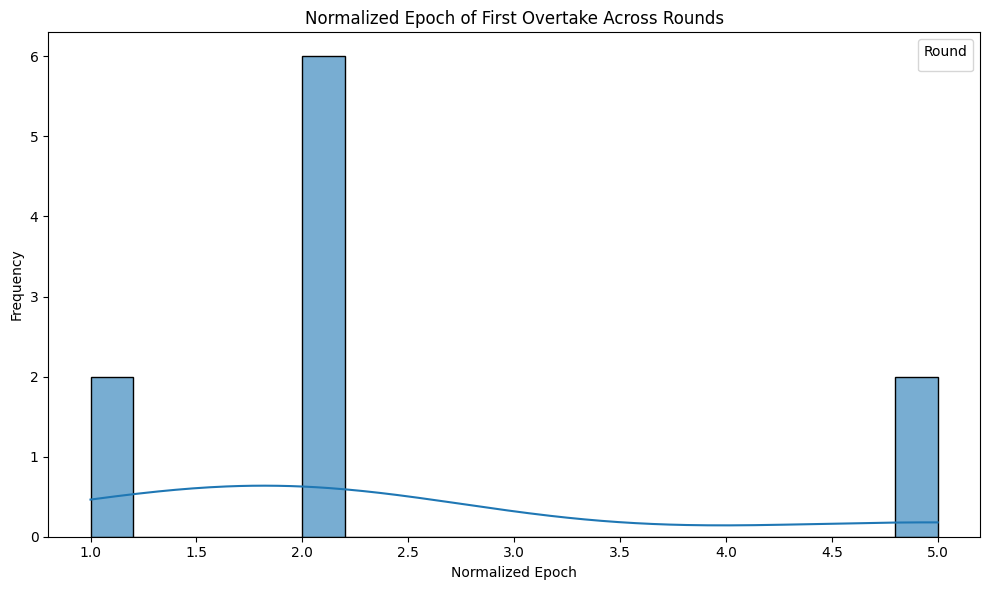

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct mapping
df["group"] = df["control_group"].map({True: "Control", False: "Treatment"})

# Pivot table
df_pivot = df.pivot(index=['run_uuid', 'round', 'full_epoch'], columns='group', values='mean_accuracy')

# Function to find first overtake epoch
def first_overtake_epoch(sub_df):
    overtake = (sub_df['Treatment'] > sub_df['Control'])
    if overtake.any():
        return sub_df.index[overtake][0][2]  # Extract full_epoch
    return np.nan

overtake_epochs = df_pivot.groupby(level=['run_uuid', 'round']).apply(first_overtake_epoch).dropna()
overtake_epochs = overtake_epochs.reset_index()
overtake_epochs.columns = ['run_uuid', 'round', 'overtake_epoch']

overtake_epochs = overtake_epochs.merge(df[['run_uuid', 'control_group']].drop_duplicates(), on='run_uuid')

epochs_per_round = full_experiment_df["epochs_per_round"].iloc[0]
overtake_epochs['norm_epoch'] = overtake_epochs['overtake_epoch'] - overtake_epochs["round"] * epochs_per_round

overtake_epochs['round'] = overtake_epochs['round'].astype(int)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=overtake_epochs,
    x="norm_epoch",
    hue="round",  # Differentiate rounds
    bins=20,
    kde=True,
    alpha=0.6,  # Adjust transparency for overlap
    palette="tab10"
)

plt.title("Normalized Epoch of First Overtake Across Rounds")
plt.xlabel("Normalized Epoch")
plt.ylabel("Frequency")
plt.legend(title="Round")  # Legend for clarity

plt.tight_layout()
plt.show()


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_76057/1397679189.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=overtake_epochs, x="round", y="norm_epoch", palette="coolwarm", inner="quartile")


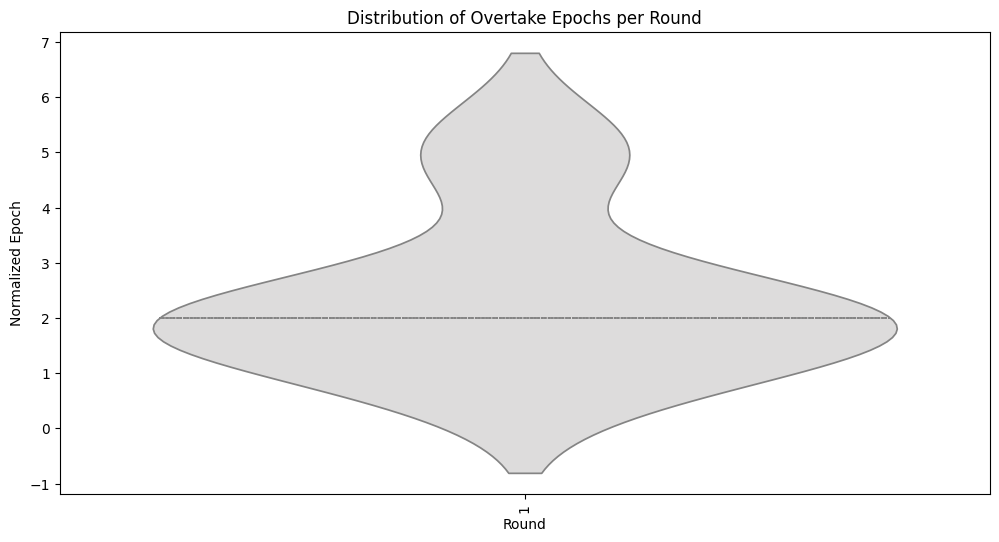

In [46]:
plt.figure(figsize=(12, 6))
sns.violinplot(data=overtake_epochs, x="round", y="norm_epoch", palette="coolwarm", inner="quartile")

plt.title("Distribution of Overtake Epochs per Round")
plt.xlabel("Round")
plt.ylabel("Normalized Epoch")
plt.xticks(rotation=90)
plt.show()


/var/folders/mx/_hhh11pd76qbpyxc0xz5m9gr0000gn/T/ipykernel_76057/1366134128.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(


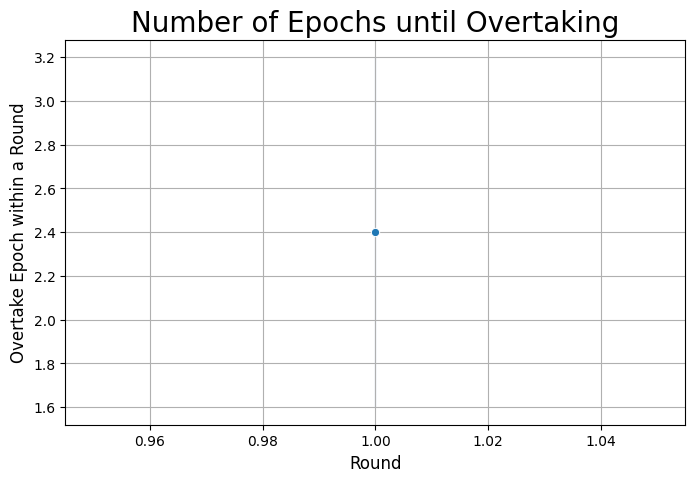

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a lineplot with confidence interval
plt.figure(figsize=(8, 5))

sns.lineplot(
    data=overtake_epochs,
    x="round",
    y="norm_epoch",
    marker="o",
    errorbar=('ci',95),  # Confidence interval at 95%
    estimator='mean',
    palette=["#8aa5d3", "#81bb91"]
)

plt.title("Number of Epochs until Overtaking", fontsize=20)
plt.xlabel("Round", fontsize=12)
plt.ylabel("Overtake Epoch within a Round", fontsize=12)

plt.grid(True)


plt.show()


#
# def plot_metrics_with_error_bands(df, metrics):
#     num_metrics = len(metrics)
#     plots_per_row = 3
#     num_rows = math.ceil(num_metrics / plots_per_row)
#     num_cols = min(num_metrics, plots_per_row)  # Ensure it adapts to num_metrics
#
#     fig, axes = plt.subplots(num_rows, num_cols, figsize=(5*num_cols, 5*num_rows))
#
#     if num_metrics == 1:
#         axes = [axes]
#     elif num_metrics > 1:
#         axes = axes.flatten() if isinstance(axes, np.ndarray) else [axes]
#
#     for i, metric in enumerate(metrics):
#         ax = axes[i]
#
#         sns.lineplot(
#             data=df[df['control_group'] == True], x='full_epoch', y=metric, ax=ax, label='Control', errorbar=("ci", 95), palette=["#8aa5d3", "#81bb91"],
#             estimator='median'
#         )
#
#         sns.lineplot(
#             data=df[df['control_group'] == False], x='full_epoch', y=metric, ax=ax, label='Experimental', errorbar=("ci", 95), palette=["#8aa5d3", "#81bb91"],
#             estimator='median'
#         )
#
#         for _, row in df.iterrows():
#             if row["full_epoch"] % row["epochs_per_round"] == 0:
#                 ax.axvline(x=row["full_epoch"], linestyle='-.', label=f"round {row['full_epoch']}", lw=0.5, color="#cf7c81")
#
#         ax.set_title(f"{metric.replace('_', ' ').replace('var', 'Variance').title()}", fontsize=20)
#         ax.set_ylabel("Value", fontsize=12)
#         ax.set_xlabel("Epoch", fontsize=12)
#
#     # Hide any unused subplots
#     for j in range(i + 1, len(axes)):
#         fig.delaxes(axes[j])
#
#     plt.tight_layout(rect=[0, 0, 1, 0.96])
#     plt.show()
#
# # metrics = ['mean_accuracy', 'var_accuracy', 'topographic_similarity']
# # metrics = ['mean_accuracy', 'topographic_similarity']
# # metrics = ['mean_accuracy']
# metrics = ['topographic_similarity']
#
# plot_metrics_with_error_bands(df, metrics)



In [48]:
    # correlation between valid acc and topographic similarity
import sklearn

[stats.spearmanr(df.loc[df["full_epoch"] == round]["mean_accuracy"], df.loc[df["full_epoch"] == round]["topographic_similarity"]) for round in df["full_epoch"].unique()]


[stats.pearsonr(df.loc[df["full_epoch"] == round]["mean_accuracy"], df.loc[df["full_epoch"] == round]["topographic_similarity"]) for round in df["full_epoch"].unique()]





print(stats.spearmanr(df["mean_accuracy"], df["topographic_similarity"]))
print(stats.pearsonr(df["mean_accuracy"], df["topographic_similarity"]))



SignificanceResult(statistic=-0.24187281917695033, pvalue=8.865959317884836e-15)
PearsonRResult(statistic=-0.13547969570686702, pvalue=1.7178767994665273e-05)


In [49]:

x = df["mean_accuracy"]
y = df["topographic_similarity"]

def statistic(x): # permute only `x`
    return stats.spearmanr(x, y).statistic

res_exact = stats.permutation_test((x,), statistic, permutation_type='pairings')

res_asymptotic = stats.spearmanr(x, y)

res_exact.pvalue, res_asymptotic.pvalue # asymptotic pvalue is too low

(0.0002, 8.865959317884836e-15)